In [1]:
import pandas as pd

In [2]:
beauty = pd.read_csv("nykaa_beauty_products.csv")
healthcare = pd.read_csv("nykaa_healthcare_products.csv")
baby = pd.read_csv("nykaa_baby_products.csv")

print("Beauty:", len(beauty))
print("Healthcare:", len(healthcare))
print("Baby:", len(baby))

Beauty: 20
Healthcare: 20
Baby: 20


In [3]:
master_df = pd.concat(
    [beauty, healthcare, baby],
    ignore_index=True
)

master_df

,Product Name,Brand,MRP,Selling Price,Discount,Rating,Reviews,Product URL,Category
0,TIRTIR Mask Fit Red Mini Cushion Foundation,TIRTIR,1300.0,1105.0,15%,NaN,2408.0,https://www.nykaa.com/tirtir-mask-fit-red-mini...,Beauty
1,"Swiss Beauty Bold Matt Lip Liner Pencil, Long-...",Swiss,69.0,66.0,5%,NaN,313242.0,https://www.nykaa.com/swiss-beauty-bold-matt-l...,Beauty
2,"Insight Cosmetics Concealer, Buildabe Coverage...",Insight,135.0,131.0,3%,NaN,38535.0,https://www.nykaa.com/insight-cosmetics-concea...,Beauty
3,Feel Good Club Classic Makeup Blender Beauty S...,Feel,105.0,60.0,43%,NaN,2355.0,https://www.nykaa.com/feel-good-club-classic-m...,Beauty
4,Biolage Smoothproof 6-in-1 Hair Serum for Friz...,Biolage,385.0,308.0,20%,NaN,42542.0,https://www.nykaa.com/matrix-biolage-smooth-pr...,Beauty
5,Beauty of Joseon Relief Sun Aqua-Fresh Add SPF...,Beauty,NaN,NaN,NaN,NaN,5431.0,https://www.nykaa.com/beauty-of-joseon-relief-...,Beauty
6,Dot & Key 10% Vitamin C + E Face Serum With 5%...,Dot,499.0,429.0,14%,NaN,63254.0,https://www.nykaa.com/dot-key-10percent-vitami...,Beauty
7,Insight Cosmetics 24 Hrs Non Transfer Matte Li...,Insight,310.0,295.0,5%,NaN,545160.0,https://www.nykaa.com/insight-cosmetics-24-hrs...,Beauty
8,Oziva Advanced Hair Growth ActivesReduces Thin...,Oziva,2099.0,1849.0,12%,NaN,280.0,https://www.nykaa.com/oziva-advanced-hair-grow...,Beauty
9,Dot & Key Cica Calming Mattifying Sunscreen In...,Dot,445.0,387.0,13%,NaN,33451.0,https://www.nykaa.com/dot-key-cica-calming-nia...,Beauty


In [4]:
master_df.to_csv("nykaa_master_products.csv", index=False)

print("Master CSV created successfully!")
print("Total products:", len(master_df))

Master CSV created successfully!
Total products: 60


### Step 4 — Handle Missing Values

In [5]:
master_df.isnull().sum()

Product Name      0
Brand             0
MRP              12
Selling Price    12
Discount         12
Rating           59
Reviews           1
Product URL       0
Category          0
dtype: int64

In [6]:
master_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   60 non-null     object 
 1   Brand          60 non-null     object 
 2   MRP            48 non-null     float64
 3   Selling Price  48 non-null     float64
 4   Discount       48 non-null     object 
 5   Rating         1 non-null      float64
 6   Reviews        59 non-null     float64
 7   Product URL    60 non-null     object 
 8   Category       60 non-null     object 
dtypes: float64(4), object(5)
memory usage: 4.3+ KB


### Step 5 — Convert Discount to Numeric

In [7]:
master_df["Discount"] = master_df["Discount"].str.replace("%", "", regex=False)
master_df["Discount"] = pd.to_numeric(master_df["Discount"], errors="coerce")

In [8]:
master_df[["Discount"]].head()

,Discount
0,15.0
1,5.0
2,3.0
3,43.0
4,20.0


In [9]:
master_df.dtypes

Product Name      object
Brand             object
MRP              float64
Selling Price    float64
Discount         float64
Rating           float64
Reviews          float64
Product URL       object
Category          object
dtype: object

### Step 6 — MRP & Selling Price check

In [10]:
master_df[master_df["MRP"].isna()][
    ["Product Name", "MRP", "Selling Price", "Discount", "Category"]
]

,Product Name,MRP,Selling Price,Discount,Category
5,Beauty of Joseon Relief Sun Aqua-Fresh Add SPF...,NaN,NaN,NaN,Beauty
10,The Face Shop Real Nature Face Mask,NaN,NaN,NaN,Beauty
12,Beauty of Joseon Relief Sunscreen Rice + Probi...,NaN,NaN,NaN,Beauty
16,Rare Beauty Soft Pinch Matte Liquid Blush,NaN,NaN,NaN,Beauty
22,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",NaN,NaN,NaN,Healthcare
30,Krishna's Herbal & Ayurveda Shapefix Juice,NaN,NaN,NaN,Healthcare
40,BABY FOREST Maasoom Maalish Baby Body Massage ...,NaN,NaN,NaN,Baby
48,BABY FOREST Dulaar Pyar Talc-Free Baby Powder ...,NaN,NaN,NaN,Baby
50,Sebamed Baby Cream Extra Soft PH5.5,NaN,NaN,NaN,Baby
54,"Sebamed Baby Rash Cream, pH 5.5, Ideal For Dia...",NaN,NaN,NaN,Baby


### Step 7 — Check Missing MRP Values

In [11]:
master_df[master_df["MRP"].isna()][
    ["Product Name", "MRP", "Selling Price", "Discount", "Category"]
]

,Product Name,MRP,Selling Price,Discount,Category
5,Beauty of Joseon Relief Sun Aqua-Fresh Add SPF...,NaN,NaN,NaN,Beauty
10,The Face Shop Real Nature Face Mask,NaN,NaN,NaN,Beauty
12,Beauty of Joseon Relief Sunscreen Rice + Probi...,NaN,NaN,NaN,Beauty
16,Rare Beauty Soft Pinch Matte Liquid Blush,NaN,NaN,NaN,Beauty
22,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",NaN,NaN,NaN,Healthcare
30,Krishna's Herbal & Ayurveda Shapefix Juice,NaN,NaN,NaN,Healthcare
40,BABY FOREST Maasoom Maalish Baby Body Massage ...,NaN,NaN,NaN,Baby
48,BABY FOREST Dulaar Pyar Talc-Free Baby Powder ...,NaN,NaN,NaN,Baby
50,Sebamed Baby Cream Extra Soft PH5.5,NaN,NaN,NaN,Baby
54,"Sebamed Baby Rash Cream, pH 5.5, Ideal For Dia...",NaN,NaN,NaN,Baby


### Step 8 — Verify Missing MRP and Selling Price

In [13]:
master_df[["MRP", "Selling Price"]].isnull().sum()

MRP              12
Selling Price    12
dtype: int64

### Step 9 — Handle Missing Reviews

In [14]:
master_df["Reviews"].isnull().sum()

np.int64(1)

In [15]:
master_df[master_df["Reviews"].isna()][
    ["Product Name", "Reviews", "Category"]
]

,Product Name,Reviews,Category
44,Old School Handmade By Grandmas Baby Ubtan Bat...,NaN,Baby


### Step 10 — Handle Missing Rating

In [16]:
master_df["Rating"].isnull().sum()


np.int64(59)

In [17]:
master_df["Rating"].value_counts(dropna=False)

Rating
NaN    59
5.5     1
Name: count, dtype: int64

### Step 11 — Check Duplicate Product

In [19]:
master_df.duplicated().sum()

np.int64(0)

In [20]:
master_df[master_df.duplicated(keep=False)]

,Product Name,Brand,MRP,Selling Price,Discount,Rating,Reviews,Product URL,Category


In [21]:
master_df[master_df["Product Name"].duplicated(keep=False)][
    ["Product Name", "Brand", "Category"]
]

,Product Name,Brand,Category
8,Oziva Advanced Hair Growth ActivesReduces Thin...,Oziva,Beauty
21,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",Be,Healthcare
22,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",Be,Healthcare
24,Oziva Advanced Hair Growth ActivesReduces Thin...,Oziva,Healthcare


### Step 12 — Remove Duplicate Rows

In [22]:
master_df = master_df.drop_duplicates()

print("Rows after removing duplicates:", len(master_df))

Rows after removing duplicates: 60


In [23]:
master_df.duplicated().sum()


np.int64(0)

### Step 13 — Check Data Types

In [24]:
master_df.dtypes

Product Name      object
Brand             object
MRP              float64
Selling Price    float64
Discount         float64
Rating           float64
Reviews          float64
Product URL       object
Category          object
dtype: object

### Step 14 — Check Final Missing Values

In [25]:
master_df.isnull().sum()

Product Name      0
Brand             0
MRP              12
Selling Price    12
Discount         12
Rating           59
Reviews           1
Product URL       0
Category          0
dtype: int64

### Step 15 — Save the Cleaned Dataset

In [26]:
master_df.to_csv("nykaa_cleaned_products.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Total rows:", len(master_df))

Cleaned dataset saved successfully!
Total rows: 60


### Step 16 — Check Category-wise Product Count 

In [27]:
master_df["Category"].value_counts()

Category
Beauty        20
Healthcare    20
Baby          20
Name: count, dtype: int64

### Step 17 — Price Analysis

In [28]:
master_df[["MRP", "Selling Price"]].describe()

,MRP,Selling Price
count,48.000000,48.000000
mean,724.625000,581.645833
std,523.229807,430.807924
min,69.000000,60.000000
25%,310.000000,290.000000
50%,549.000000,456.500000
75%,1011.750000,855.250000
max,2099.000000,1849.000000


### Step 18 — Category-wise Average Price

In [29]:
master_df.groupby("Category")[["MRP", "Selling Price"]].mean()

,MRP,Selling Price
Category,,
Baby,589.428571,504.285714
Beauty,539.687500,459.062500
Healthcare,994.166667,750.777778


### Step 19 — Category-wise Average Discount

In [30]:
master_df.groupby("Category")["Discount"].mean().round(2)

Category
Baby          14.36
Beauty        15.81
Healthcare    23.22
Name: Discount, dtype: float64

### Step 20 — Top Discounted Products

In [31]:
master_df[["Product Name", "Category", "Discount"]].sort_values(
    by="Discount",
    ascending=False
).head(10)

,Product Name,Category,Discount
57,Bronson Professional Transparent Waterproof Po...,Baby,63.0
27,Be Bodywise Collagen Builder Gummies Vitamins ...,Healthcare,55.0
37,MYPRO SPORT NUTRITION High Protein Women Weigh...,Healthcare,50.0
38,Chicnutrix Mighty Collagen Japanese Marine Col...,Healthcare,44.0
3,Feel Good Club Classic Makeup Blender Beauty S...,Beauty,43.0
39,Carbamide Forte Japanese Reduced L Glutathione...,Healthcare,35.0
34,TruNativ Everyday Sweet 1:1 Sugar Replacer,Healthcare,33.0
28,What's Up Wellness Glutathione Gummies with Vi...,Healthcare,28.0
26,HealthKart Hk Vitals Multivitamin + Fish Oil,Healthcare,27.0
52,Mustela Gentle Cleansing Gel,Baby,26.0


### Step 21 — Top Reviewed Products

In [32]:
master_df[["Product Name", "Category", "Reviews"]].sort_values(
    by="Reviews",
    ascending=False
).head(10)

,Product Name,Category,Reviews
11,Nykaa Green Tea + Aloe Vera Sheet Mask For Hyd...,Beauty,7593355.0
7,Insight Cosmetics 24 Hrs Non Transfer Matte Li...,Beauty,545160.0
1,"Swiss Beauty Bold Matt Lip Liner Pencil, Long-...",Beauty,313242.0
18,Aqualogica Glow+ Dewy Sunscreen Gel SPF 50+ PA...,Beauty,200409.0
10,The Face Shop Real Nature Face Mask,Beauty,181063.0
14,Kay Beauty Matte Compact,Beauty,171931.0
53,Max Care Virgin Coconut Oil Cold Pressed,Baby,104248.0
6,Dot & Key 10% Vitamin C + E Face Serum With 5%...,Beauty,63254.0
15,Swiss Beauty Baked Blusher & Highlighter,Beauty,49547.0
13,Dot & Key 72HR Hydrating Gel Moisturizer + Pro...,Beauty,43737.0


### Step 22 — Category-wise Average Reviews

In [33]:
master_df.groupby("Category")["Reviews"].mean().round(2)

Category
Baby            7727.00
Beauty        467003.55
Healthcare      2078.30
Name: Reviews, dtype: float64

### Step 23 — Top Brands by Product Count

In [34]:
master_df["Brand"].value_counts().head(10)

Brand
Cetaphil    4
Be          3
What's      3
Dot         3
Swiss       3
Aveeno      3
Sebamed     3
Oziva       2
Insight     2
BABY        2
Name: count, dtype: int64

### Step 24 — Average Price by Brand

In [35]:
master_df.groupby("Brand")["Selling Price"].mean().sort_values(ascending=False).head(10).round(2)

Brand
Oziva         1849.00
Wellbeing     1357.00
TIRTIR        1105.00
Mustela        999.00
Chicnutrix     999.00
Old            874.00
Carbamide      816.00
Aveeno         812.67
What's         782.33
HealthKart     699.00
Name: Selling Price, dtype: float64

### Step 25 — Category-wise Product Count

In [36]:
master_df["Category"].value_counts()

Category
Beauty        20
Healthcare    20
Baby          20
Name: count, dtype: int64

### Step 26 — Price Comparison by Category

In [37]:
master_df.groupby("Category")[["MRP", "Selling Price"]].mean().round(2)

,MRP,Selling Price
Category,,
Baby,589.43,504.29
Beauty,539.69,459.06
Healthcare,994.17,750.78


### Step 27 — Discount vs Selling Price Analysis

In [38]:
master_df[["Product Name", "Category", "Selling Price", "Discount"]].sort_values(
    by="Discount",
    ascending=False
).head(10)

,Product Name,Category,Selling Price,Discount
57,Bronson Professional Transparent Waterproof Po...,Baby,120.0,63.0
27,Be Bodywise Collagen Builder Gummies Vitamins ...,Healthcare,449.0,55.0
37,MYPRO SPORT NUTRITION High Protein Women Weigh...,Healthcare,599.0,50.0
38,Chicnutrix Mighty Collagen Japanese Marine Col...,Healthcare,999.0,44.0
3,Feel Good Club Classic Makeup Blender Beauty S...,Beauty,60.0,43.0
39,Carbamide Forte Japanese Reduced L Glutathione...,Healthcare,816.0,35.0
34,TruNativ Everyday Sweet 1:1 Sugar Replacer,Healthcare,200.0,33.0
28,What's Up Wellness Glutathione Gummies with Vi...,Healthcare,1149.0,28.0
26,HealthKart Hk Vitals Multivitamin + Fish Oil,Healthcare,489.0,27.0
52,Mustela Gentle Cleansing Gel,Baby,999.0,26.0


In [39]:
master_df[["Discount", "Selling Price"]].corr()

,Discount,Selling Price
Discount,1.000000,-0.097975
Selling Price,-0.097975,1.000000


### Step 28 — Price Reduction Analysis

In [40]:
price_analysis = master_df.groupby("Category")[["MRP", "Selling Price"]].mean()

price_analysis["Price Reduction"] = (
    price_analysis["MRP"] - price_analysis["Selling Price"]
).round(2)

price_analysis

,MRP,Selling Price,Price Reduction
Category,,,
Baby,589.428571,504.285714,85.14
Beauty,539.687500,459.062500,80.62
Healthcare,994.166667,750.777778,243.39


### Step 29 — Category-wise Price Reduction %

In [41]:
price_analysis["Price Reduction %"] = (
    (price_analysis["MRP"] - price_analysis["Selling Price"])
    / price_analysis["MRP"] * 100
).round(2)

price_analysis

,MRP,Selling Price,Price Reduction,Price Reduction %
Category,,,,
Baby,589.428571,504.285714,85.14,14.44
Beauty,539.687500,459.062500,80.62,14.94
Healthcare,994.166667,750.777778,243.39,24.48


### Step 30 — Category-wise Analysis Summary

In [45]:
summary = master_df.groupby("Category").agg(
    Product_Count=("Product Name", "count"),
    Avg_MRP=("MRP", "mean"),
    Avg_Selling_Price=("Selling Price", "mean"),
    Avg_Discount=("Discount", "mean"),
    Avg_Reviews=("Reviews", "mean")
).round(2)

summary

,Product_Count,Avg_MRP,Avg_Selling_Price,Avg_Discount,Avg_Reviews
Category,,,,,
Baby,20,589.43,504.29,14.36,7727.00
Beauty,20,539.69,459.06,15.81,467003.55
Healthcare,20,994.17,750.78,23.22,2078.30


### Step 31 — Key Business Insights

In [46]:
summary

,Product_Count,Avg_MRP,Avg_Selling_Price,Avg_Discount,Avg_Reviews
Category,,,,,
Baby,20,589.43,504.29,14.36,7727.00
Beauty,20,539.69,459.06,15.81,467003.55
Healthcare,20,994.17,750.78,23.22,2078.30


### Visualization 1 — Product Count by Category

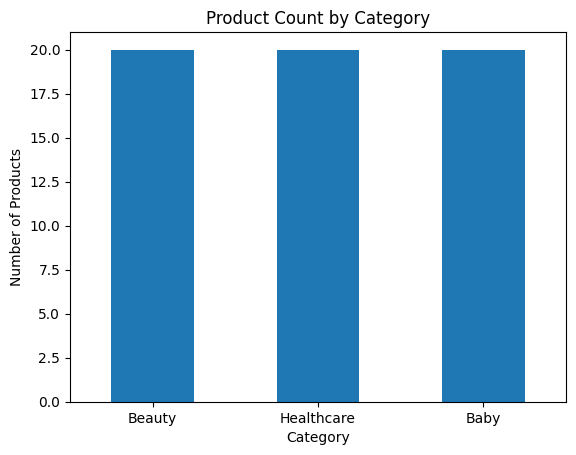

In [47]:
import matplotlib.pyplot as plt

master_df["Category"].value_counts().plot(kind="bar")

plt.title("Product Count by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.show()

### Visualization 2 — Average Selling Price by Category

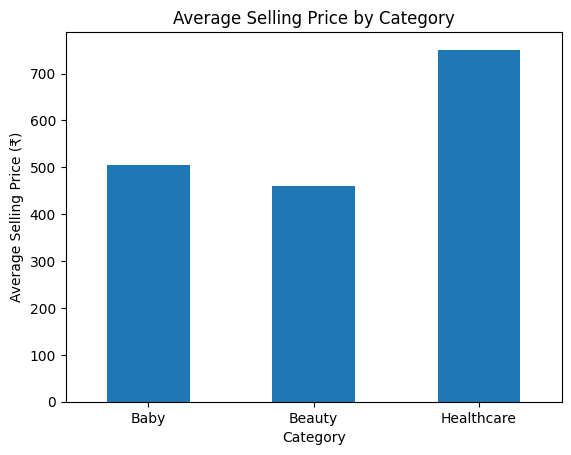

In [48]:
avg_price = master_df.groupby("Category")["Selling Price"].mean()

avg_price.plot(kind="bar")

plt.title("Average Selling Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Selling Price (₹)")
plt.xticks(rotation=0)
plt.show()

### Visualization 3 — Average Discount by Category

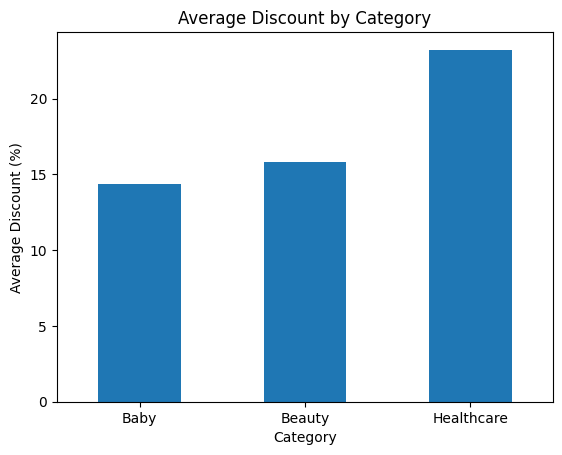

In [49]:
avg_discount = master_df.groupby("Category")["Discount"].mean()

avg_discount.plot(kind="bar")

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount (%)")
plt.xticks(rotation=0)
plt.show()

### Visualization 4 — Average Reviews by Category

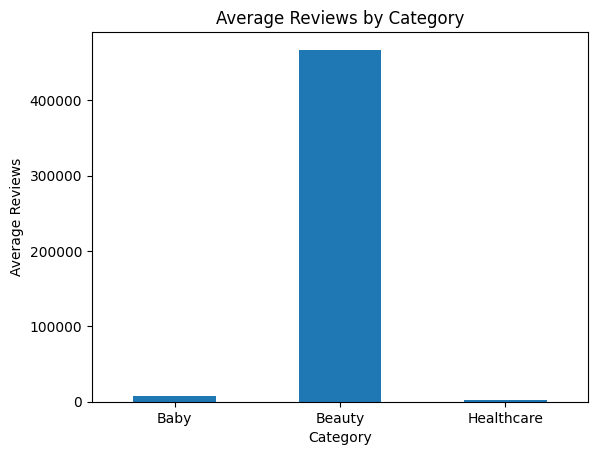

In [50]:
avg_reviews = master_df.groupby("Category")["Reviews"].mean()

avg_reviews.plot(kind="bar")

plt.title("Average Reviews by Category")
plt.xlabel("Category")
plt.ylabel("Average Reviews")
plt.xticks(rotation=0)
plt.show()

### Visualization 5 — MRP vs Selling Price by Category

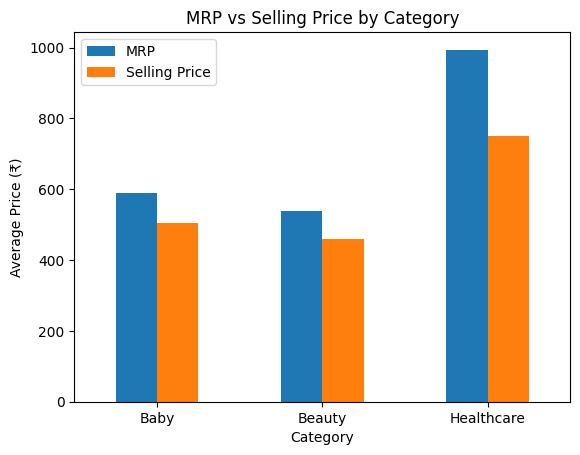

In [51]:
price_comparison = master_df.groupby("Category")[["MRP", "Selling Price"]].mean()

price_comparison.plot(kind="bar")

plt.title("MRP vs Selling Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=0)
plt.legend(["MRP", "Selling Price"])

plt.show()

### Visualization 6 — Top 10 Products by Reviews

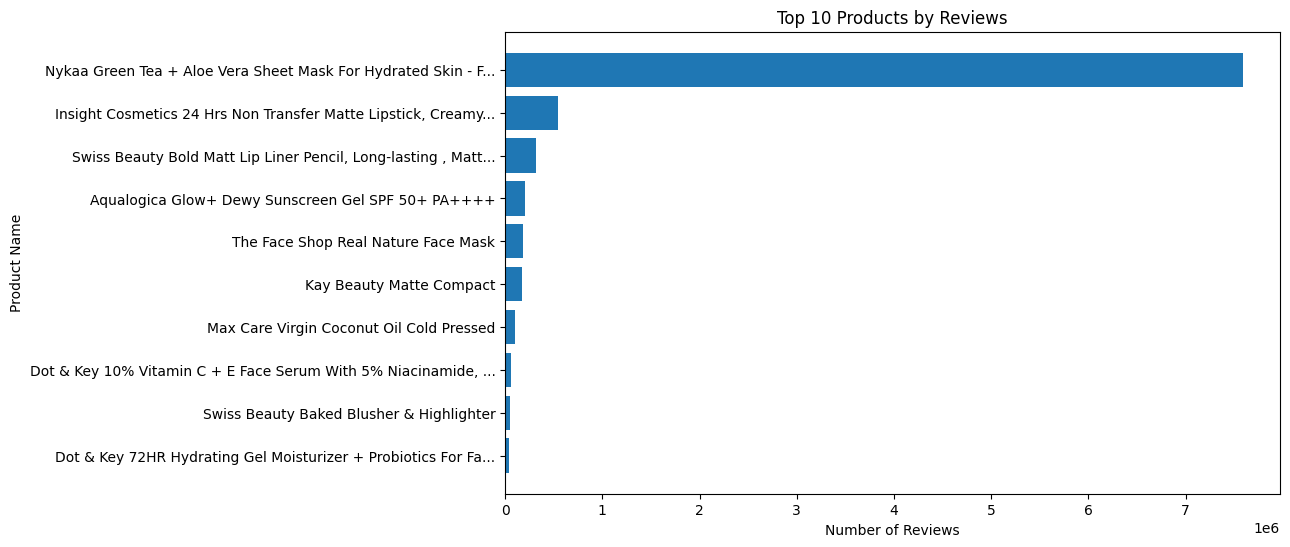

In [52]:
top_reviews = master_df.sort_values(
    by="Reviews",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_reviews["Product Name"],
    top_reviews["Reviews"]
)

plt.title("Top 10 Products by Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()

plt.show()

### Visualization 7 — Top 10 Products by Discount

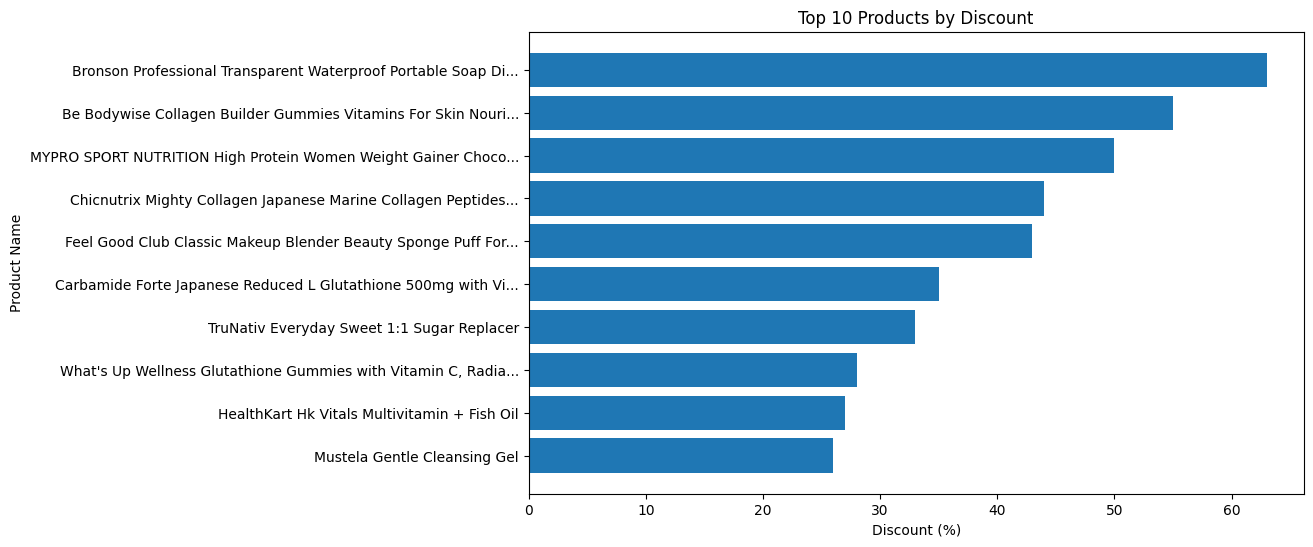

In [53]:
top_discount = master_df.sort_values(
    by="Discount",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_discount["Product Name"],
    top_discount["Discount"]
)

plt.title("Top 10 Products by Discount")
plt.xlabel("Discount (%)")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()

plt.show()

### Visualization 8 — Average Selling Price by Brand

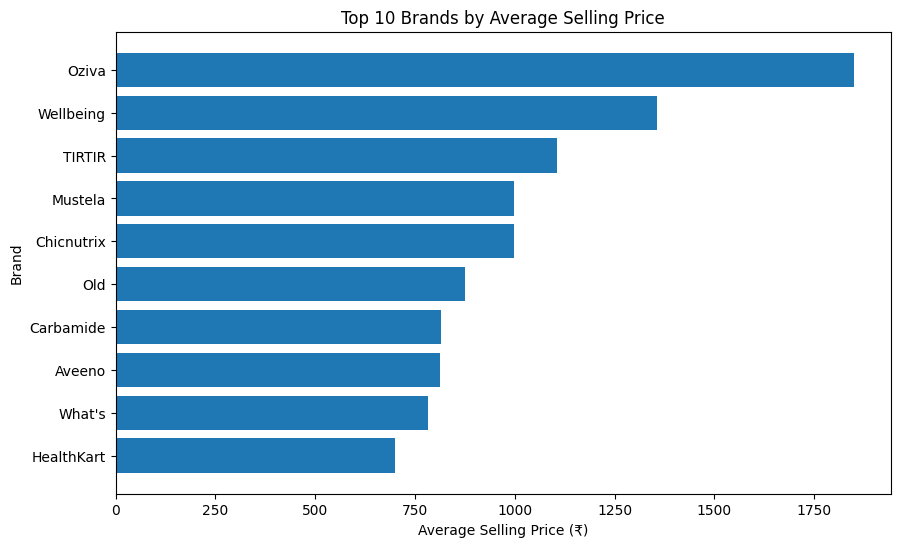

In [54]:
avg_brand_price = (
    master_df.groupby("Brand")["Selling Price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    avg_brand_price.index,
    avg_brand_price.values
)

plt.title("Top 10 Brands by Average Selling Price")
plt.xlabel("Average Selling Price (₹)")
plt.ylabel("Brand")
plt.gca().invert_yaxis()

plt.show()

### Visualization 9 — Average Discount by Brand

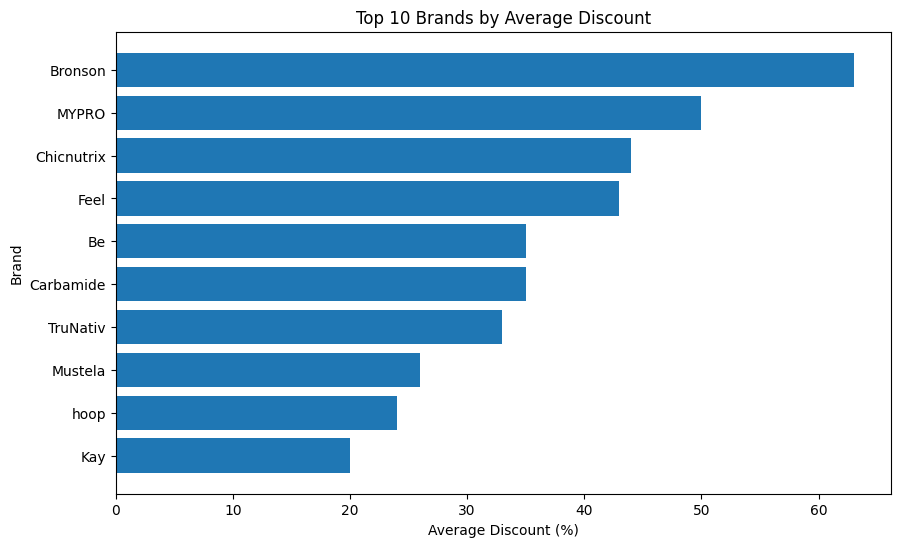

In [55]:
avg_brand_discount = (
    master_df.groupby("Brand")["Discount"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    avg_brand_discount.index,
    avg_brand_discount.values
)

plt.title("Top 10 Brands by Average Discount")
plt.xlabel("Average Discount (%)")
plt.ylabel("Brand")
plt.gca().invert_yaxis()

plt.show()

### Visualization 10 — Category-wise Price Reduction

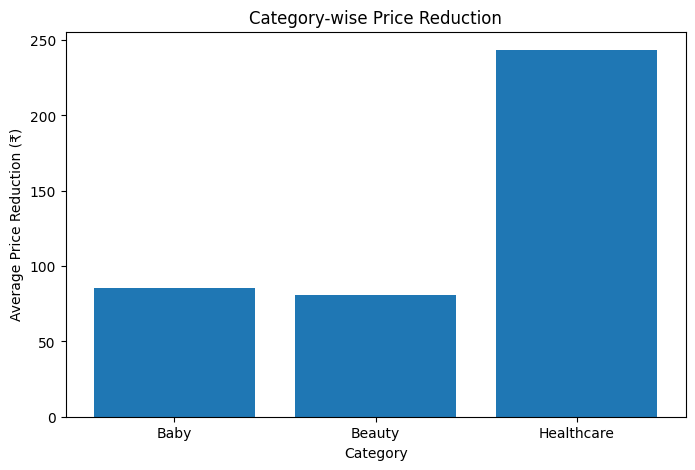

In [56]:
price_reduction = (
    master_df.groupby("Category")[["MRP", "Selling Price"]]
    .mean()
)

price_reduction["Price Reduction"] = (
    price_reduction["MRP"] - price_reduction["Selling Price"]
)

plt.figure(figsize=(8, 5))

plt.bar(
    price_reduction.index,
    price_reduction["Price Reduction"]
)

plt.title("Category-wise Price Reduction")
plt.xlabel("Category")
plt.ylabel("Average Price Reduction (₹)")
plt.xticks(rotation=0)

plt.show()

### Visualization 11 — Average MRP by Category

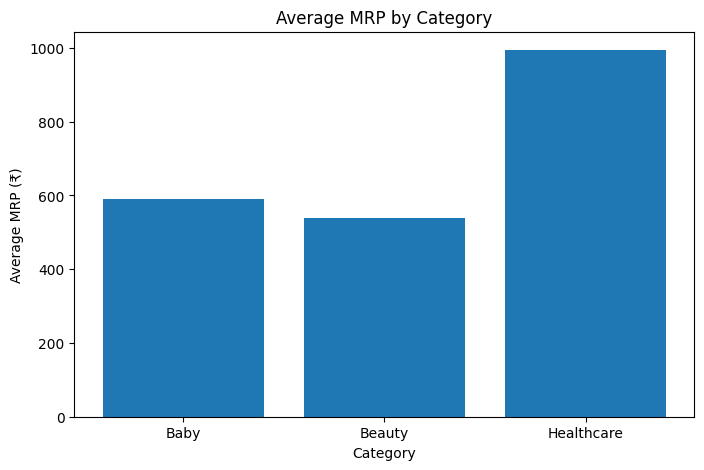

In [57]:
avg_mrp = master_df.groupby("Category")["MRP"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    avg_mrp.index,
    avg_mrp.values
)

plt.title("Average MRP by Category")
plt.xlabel("Category")
plt.ylabel("Average MRP (₹)")
plt.xticks(rotation=0)

plt.show()

### Visualization 12 — Category-wise Average Discount vs Price Reduction

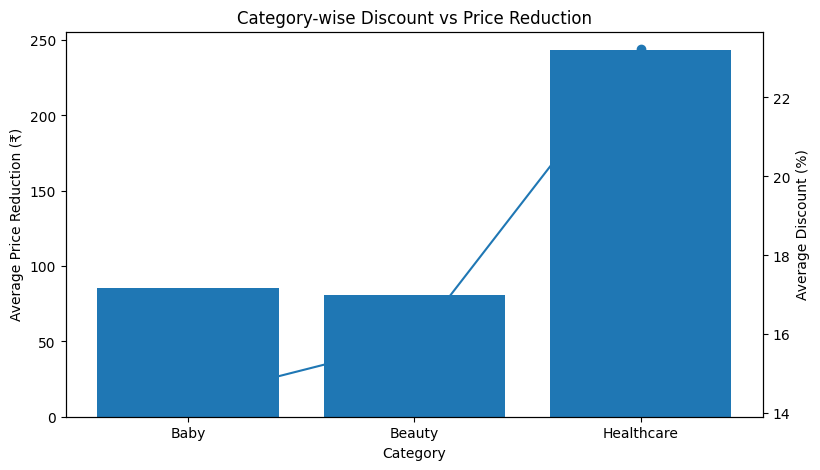

In [58]:
category_analysis = master_df.groupby("Category")[["MRP", "Selling Price", "Discount"]].mean()

category_analysis["Price Reduction"] = (
    category_analysis["MRP"] - category_analysis["Selling Price"]
)

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(
    category_analysis.index,
    category_analysis["Price Reduction"]
)

ax1.set_xlabel("Category")
ax1.set_ylabel("Average Price Reduction (₹)")
ax1.set_title("Category-wise Discount vs Price Reduction")

ax2 = ax1.twinx()

ax2.plot(
    category_analysis.index,
    category_analysis["Discount"],
    marker="o"
)

ax2.set_ylabel("Average Discount (%)")

plt.show()

### Visualization 13 — Selling Price Distribution by Category

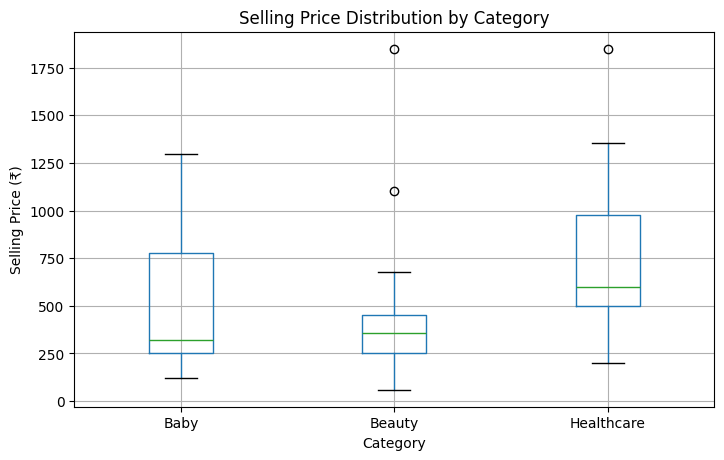

In [59]:
master_df.boxplot(
    column="Selling Price",
    by="Category",
    figsize=(8, 5)
)

plt.title("Selling Price Distribution by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Selling Price (₹)")

plt.show()

### Visualization 14 — Selling Price vs Discount

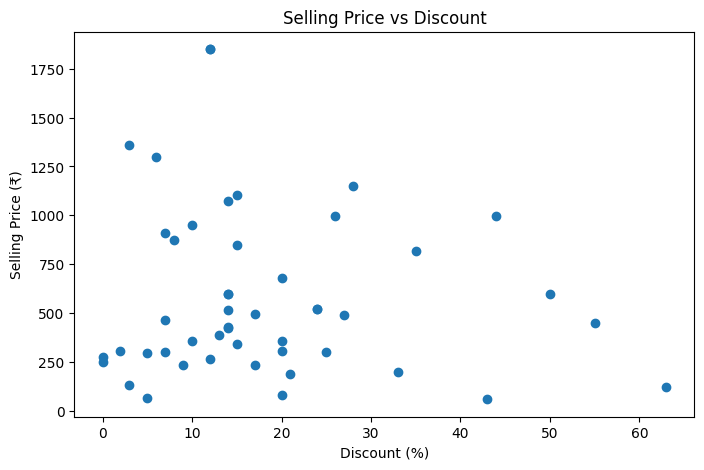

In [60]:
plt.figure(figsize=(8, 5))

plt.scatter(
    master_df["Discount"],
    master_df["Selling Price"]
)

plt.title("Selling Price vs Discount")
plt.xlabel("Discount (%)")
plt.ylabel("Selling Price (₹)")

plt.show()

### Visualization 15 — Product Count by Brand

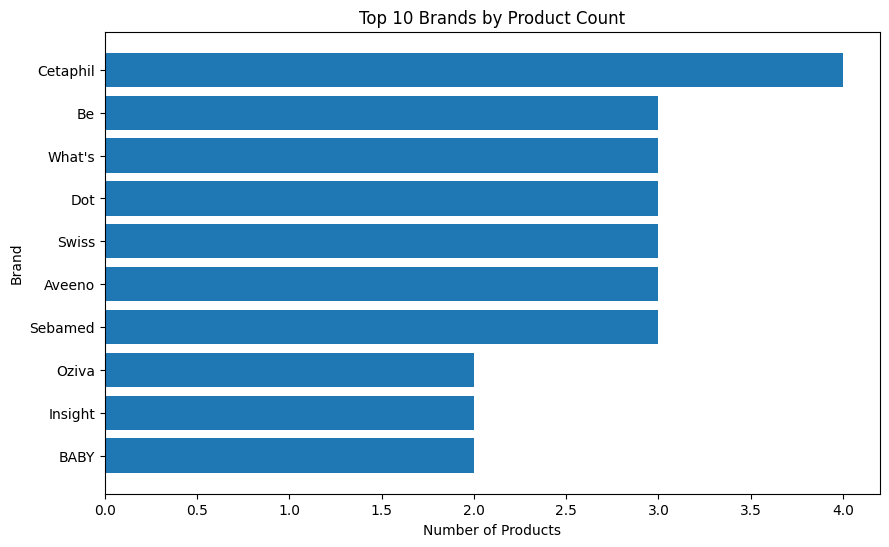

In [61]:
brand_counts = (
    master_df["Brand"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    brand_counts.index,
    brand_counts.values
)

plt.title("Top 10 Brands by Product Count")
plt.xlabel("Number of Products")
plt.ylabel("Brand")
plt.gca().invert_yaxis()

plt.show()

### Visualization 16 — Top 10 Products by Selling Price

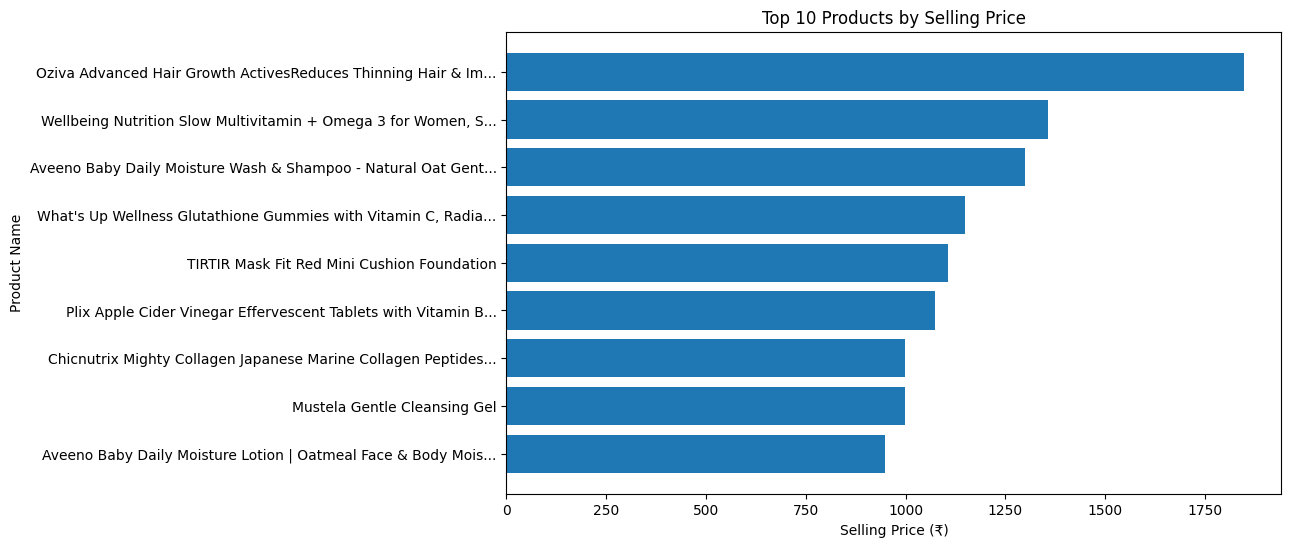

In [62]:
top_price = (
    master_df
    .sort_values(by="Selling Price", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_price["Product Name"],
    top_price["Selling Price"]
)

plt.title("Top 10 Products by Selling Price")
plt.xlabel("Selling Price (₹)")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()

plt.show()

### Visualization 17 — Average Reviews by Category

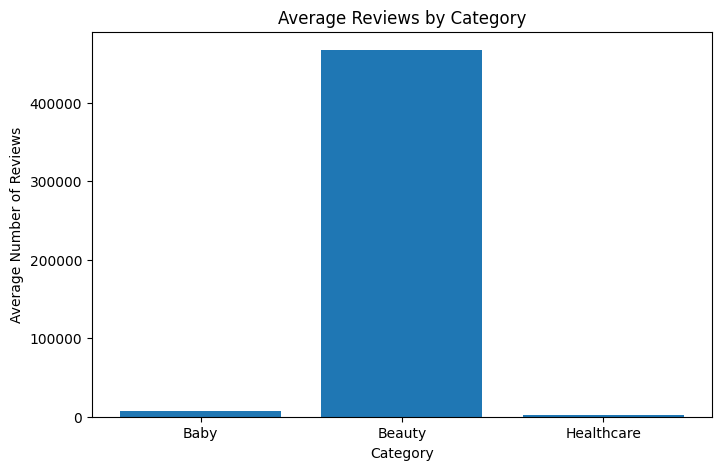

In [63]:
avg_reviews = master_df.groupby("Category")["Reviews"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    avg_reviews.index,
    avg_reviews.values
)

plt.title("Average Reviews by Category")
plt.xlabel("Category")
plt.ylabel("Average Number of Reviews")
plt.xticks(rotation=0)

plt.show()

### Visualization 18 — Average Selling Price by Category

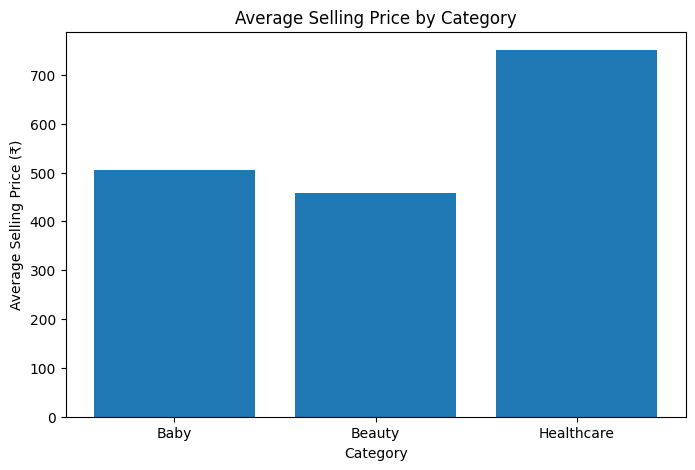

In [65]:
avg_selling_price = (
    master_df.groupby("Category")["Selling Price"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    avg_selling_price.index,
    avg_selling_price.values
)

plt.title("Average Selling Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Selling Price (₹)")
plt.xticks(rotation=0)

plt.show()

### Visualization 19 — Average MRP vs Selling Price by Category

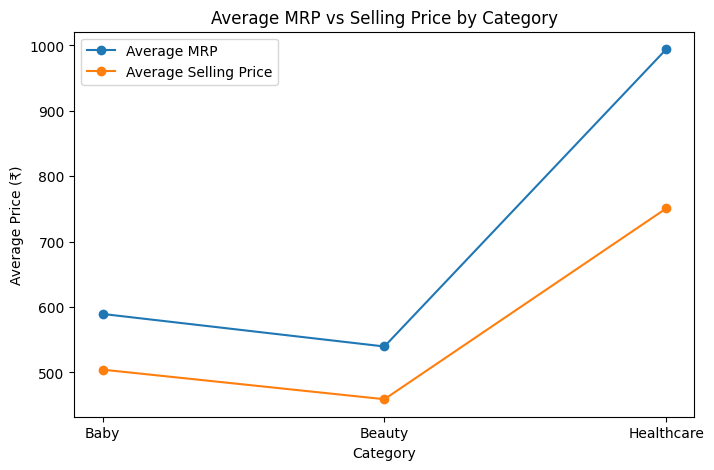

In [66]:
price_comparison = master_df.groupby("Category")[["MRP", "Selling Price"]].mean()

plt.figure(figsize=(8, 5))

plt.plot(
    price_comparison.index,
    price_comparison["MRP"],
    marker="o",
    label="Average MRP"
)

plt.plot(
    price_comparison.index,
    price_comparison["Selling Price"],
    marker="o",
    label="Average Selling Price"
)

plt.title("Average MRP vs Selling Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (₹)")
plt.legend()

plt.show()

### Visualization 20 — Category-wise Product Analysis

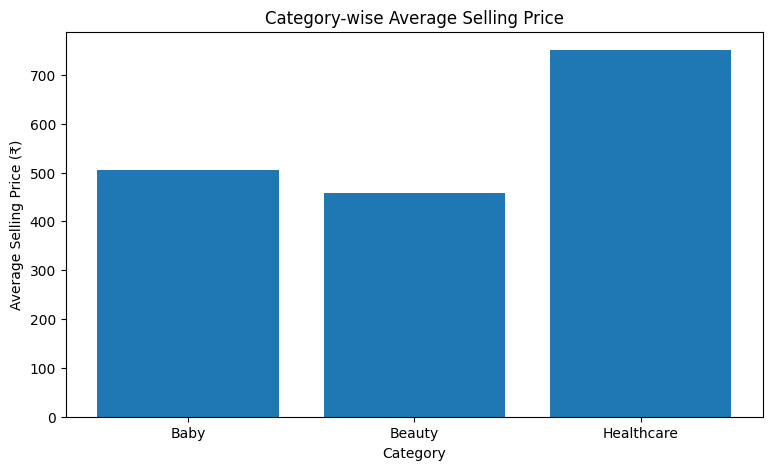

In [67]:
category_summary = master_df.groupby("Category").agg(
    Avg_Selling_Price=("Selling Price", "mean"),
    Avg_Discount=("Discount", "mean"),
    Avg_Reviews=("Reviews", "mean")
)

plt.figure(figsize=(9, 5))

plt.bar(
    category_summary.index,
    category_summary["Avg_Selling_Price"]
)

plt.title("Category-wise Average Selling Price")
plt.xlabel("Category")
plt.ylabel("Average Selling Price (₹)")
plt.xticks(rotation=0)

plt.show()